<a href="https://colab.research.google.com/github/Rancor06/Salman-Inten-Projects/blob/main/Phase%202/Day%2017/Day_17_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()

sns.set_theme(style="whitegrid")

df = pd.read_csv("student_performance.csv")

df.head()

Saving student_performance.csv to student_performance.csv


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


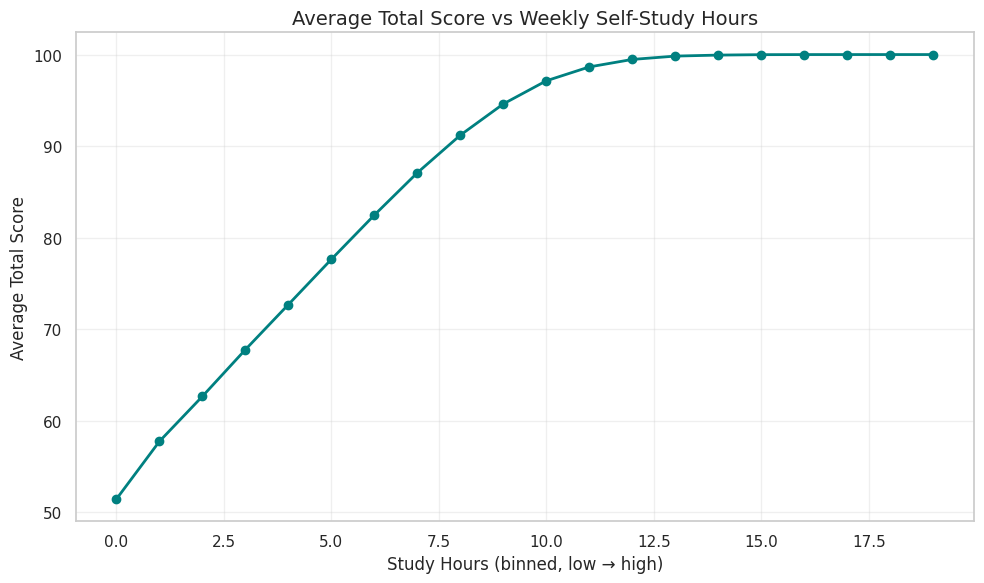

In [2]:
# Line Chart
study_bins = pd.cut(df['weekly_self_study_hours'], bins=20)
trend = df.groupby(study_bins, observed=True)['total_score'].mean()

plt.figure(figsize=(10, 6))
plt.plot(range(len(trend)), trend.values, marker='o', color='teal', linewidth=2)
plt.title("Average Total Score vs Weekly Self-Study Hours", fontsize=14)
plt.xlabel("Study Hours (binned, low → high)")
plt.ylabel("Average Total Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

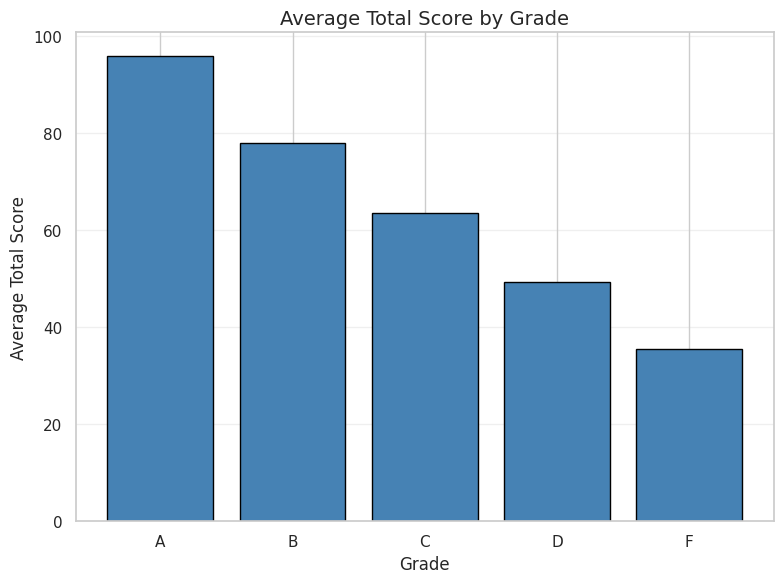

In [3]:
# Bar Chart
avg_score_by_grade = df.groupby('grade', observed=True)['total_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
plt.bar(avg_score_by_grade.index, avg_score_by_grade.values, color='steelblue', edgecolor='black')
plt.title("Average Total Score by Grade", fontsize=14)
plt.xlabel("Grade")
plt.ylabel("Average Total Score")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

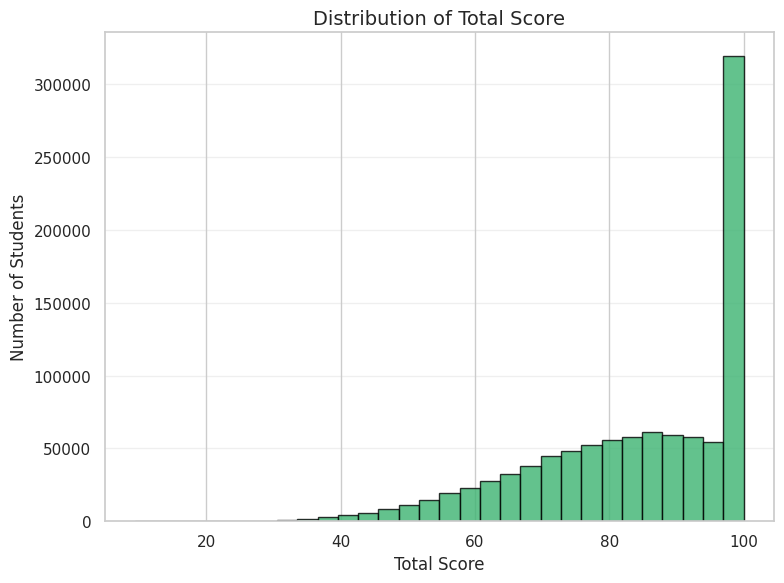

In [4]:
# Histogram
plt.figure(figsize=(8, 6))
plt.hist(df['total_score'], bins=30, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.title("Distribution of Total Score", fontsize=14)
plt.xlabel("Total Score")
plt.ylabel("Number of Students")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

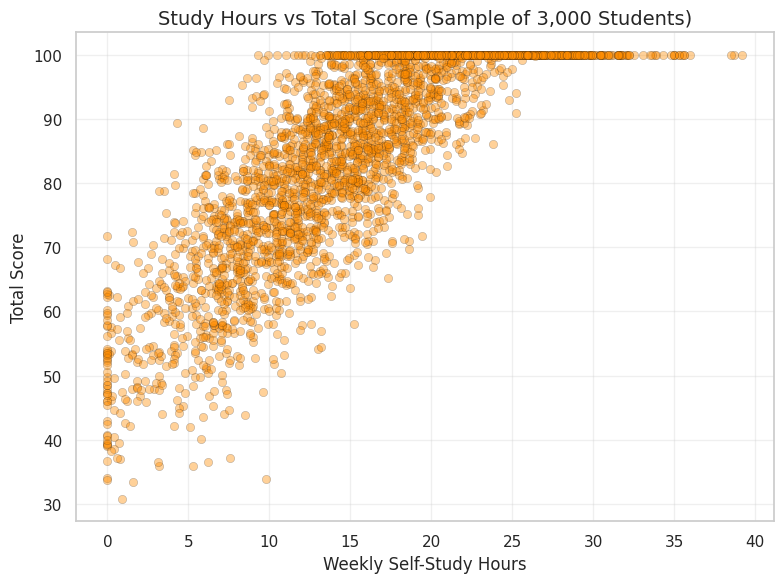

In [5]:
# Scatter Plot
sample = df.sample(3000, random_state=42)  # random sample for readable plotting

plt.figure(figsize=(8, 6))
plt.scatter(sample['weekly_self_study_hours'], sample['total_score'],
            alpha=0.4, color='darkorange', edgecolor='k', linewidth=0.3)
plt.title("Study Hours vs Total Score (Sample of 3,000 Students)", fontsize=14)
plt.xlabel("Weekly Self-Study Hours")
plt.ylabel("Total Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

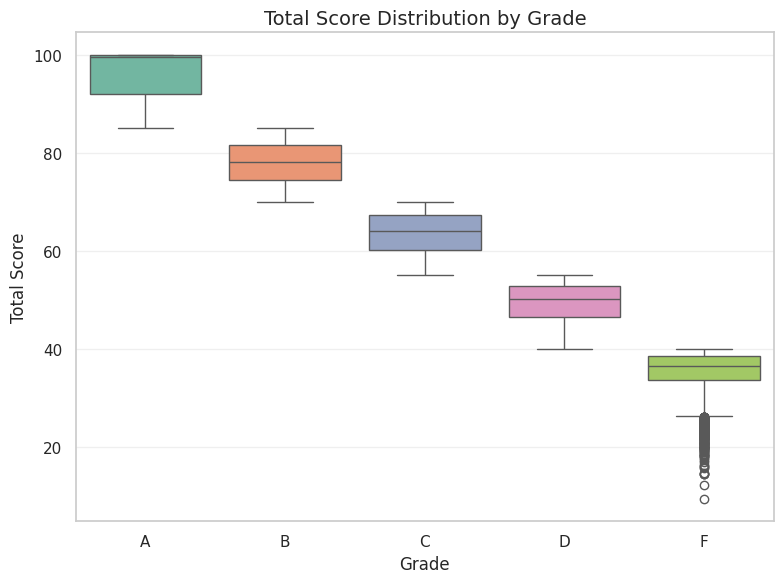

In [6]:
# Box Plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='grade', y='total_score', order=sorted(df['grade'].unique()),
            hue='grade', palette='Set2', legend=False)
plt.title("Total Score Distribution by Grade", fontsize=14)
plt.xlabel("Grade")
plt.ylabel("Total Score")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

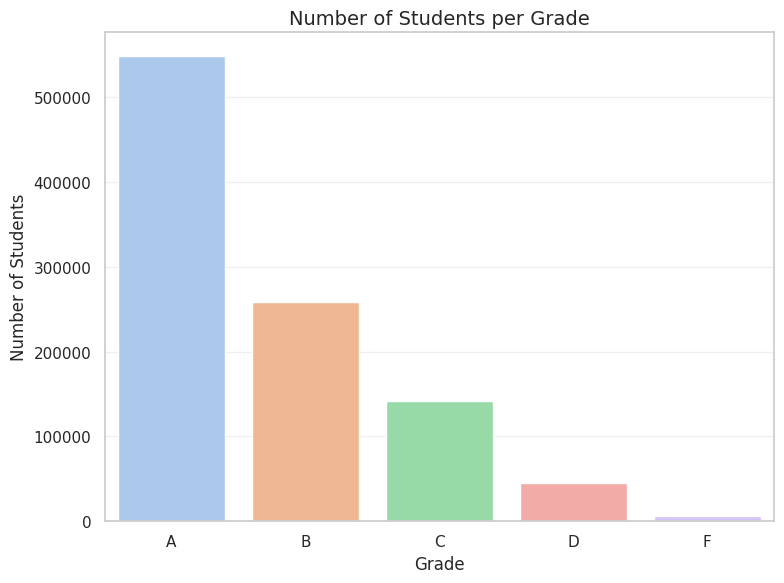

In [7]:
# Count Plot
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='grade', order=sorted(df['grade'].unique()),
              hue='grade', palette='pastel', legend=False)
plt.title("Number of Students per Grade", fontsize=14)
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

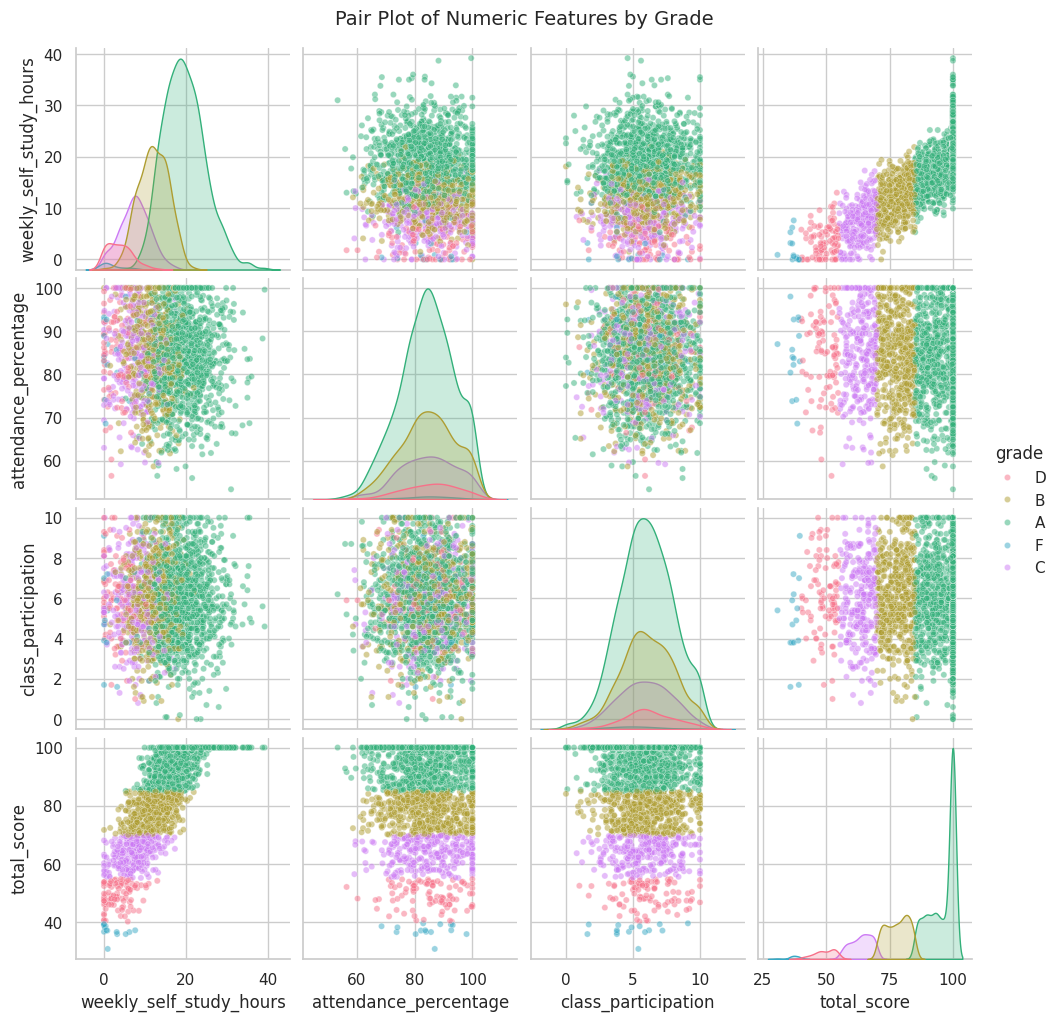

In [8]:
# Bonus Pair Plot
sample = df.sample(2000, random_state=42)  # smaller sample — pair plots are expensive to render

numeric_cols = ['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']

sns.pairplot(sample[numeric_cols + ['grade']], hue='grade', palette='husl',
             diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle("Pair Plot of Numeric Features by Grade", y=1.02, fontsize=14)
plt.show()